# PHARMALENS AI — PROJECT 12: SCENARIO PLANNING

Scenario engine for Base Case, Upside and Downside planning. Uses the processed parquet dataset and can optionally connect Project 11 patient-flow inputs.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Project Root:', PROJECT_ROOT)


Project Root: D:\learning\Epsilon\Data Science\PDF lec\Decodelab\PharmaLens AI


In [4]:
from src.scenario import (
    DEFAULT_SCENARIOS,
    load_data,
    calculate_baseline,
    run_market_scenarios,
    run_brand_scenarios,
    add_opportunity_scores,
    downside_risk,
    run_patient_flow_scenarios,
    scenario_engine,
)

df = load_data(project_root=PROJECT_ROOT)
print('Dataset shape:', df.shape)
print('Date range:', df['Month'].min(), '→', df['Month'].max())
print('Columns:', list(df.columns))


Dataset shape: (909922, 18)
Date range: 2021-01-01 00:00:00 → 2025-12-01 00:00:00
Columns: ['Distribution Channel', 'Therapeutic Class', 'Manufacturer', 'Brand Name', 'Pack Size', 'Product Launch', 'Drug Strength', 'Selling Price', 'Market Category', 'Month', 'Year', 'Sales Units', 'Sales Value', 'Revenue_per_Unit', 'Launch_Year', 'Product_Age_Years', 'New_Product_Flag', 'Month_Number']


## 1. Scenario assumptions


In [5]:
SCENARIOS = DEFAULT_SCENARIOS
pd.DataFrame(SCENARIOS).T


,market_growth,unit_growth,price_change,diagnosis_rate_change,treatment_rate_change,competition_change
Base Case,0.10,0.08,0.02,0.00,0.00,0.00
Upside,0.15,0.12,0.03,0.05,0.05,-0.03
Downside,0.05,0.03,0.00,-0.05,-0.05,0.05


## 2. Historical baseline


In [6]:
baseline = calculate_baseline(df, months=12)
print('Baseline period:', baseline['baseline_start'], '→', baseline['latest_month'])
print('Baseline market value:', baseline['market_value'])
print('Baseline market units:', baseline['market_units'])


Baseline period: 2025-01-01 00:00:00 → 2025-12-01 00:00:00
Baseline market value: 292057810603.73206
Baseline market units: 3133509680.0


In [7]:
annual_market = (
    df.assign(Year=df['Month'].dt.year)
      .groupby('Year', as_index=False)
      .agg(Sales_Value=('Sales Value','sum'), Sales_Units=('Sales Units','sum'))
      .sort_values('Year')
)
annual_market['Value_Growth_%'] = annual_market['Sales_Value'].pct_change() * 100
annual_market['Unit_Growth_%'] = annual_market['Sales_Units'].pct_change() * 100
annual_market


,Year,Sales_Value,Sales_Units,Value_Growth_%,Unit_Growth_%
0,2021,1.060877e+11,3.156214e+09,NaN,NaN
1,2022,1.189950e+11,3.151510e+09,12.166627,-0.149017
2,2023,1.485131e+11,2.926680e+09,24.806131,-7.134060
3,2024,2.172278e+11,2.942498e+09,46.268448,0.540496
4,2025,2.920578e+11,3.133510e+09,34.447708,6.491471


## 3. Market scenarios


In [8]:
market_scenarios = run_market_scenarios(df, SCENARIOS, months=12)
display(market_scenarios)


,Scenario,Baseline_Market_Value,Projected_Market_Value,Market_Value_Growth_%,Incremental_Revenue,Baseline_Units,Projected_Units,Unit_Growth_%,Price_Change_%,Diagnosis_Rate_Change_%,Treatment_Rate_Change_%,Competition_Change_%
0,Base Case,2.920578e+11,3.212636e+11,10.0,2.920578e+10,3.133510e+09,3.384190e+09,8.0,2.0,0.0,0.0,0.0
1,Upside,2.920578e+11,3.358665e+11,15.0,4.380867e+10,3.133510e+09,3.509531e+09,12.0,3.0,5.0,5.0,-3.0
2,Downside,2.920578e+11,3.066607e+11,5.0,1.460289e+10,3.133510e+09,3.227515e+09,3.0,0.0,-5.0,-5.0,5.0


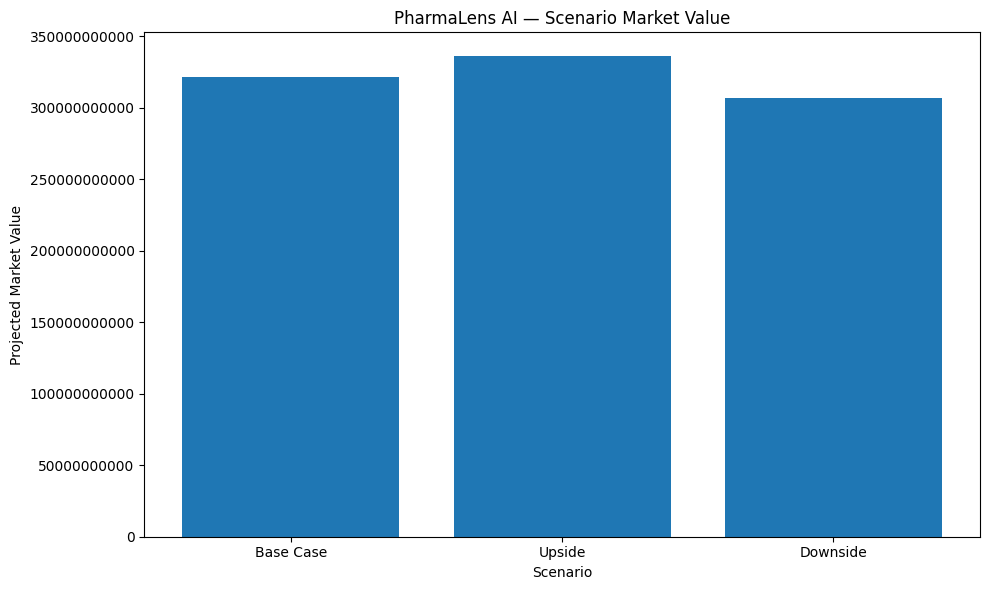

In [9]:
plt.figure(figsize=(10, 6))
plt.bar(market_scenarios['Scenario'], market_scenarios['Projected_Market_Value'])
plt.title('PharmaLens AI — Scenario Market Value')
plt.xlabel('Scenario')
plt.ylabel('Projected Market Value')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()


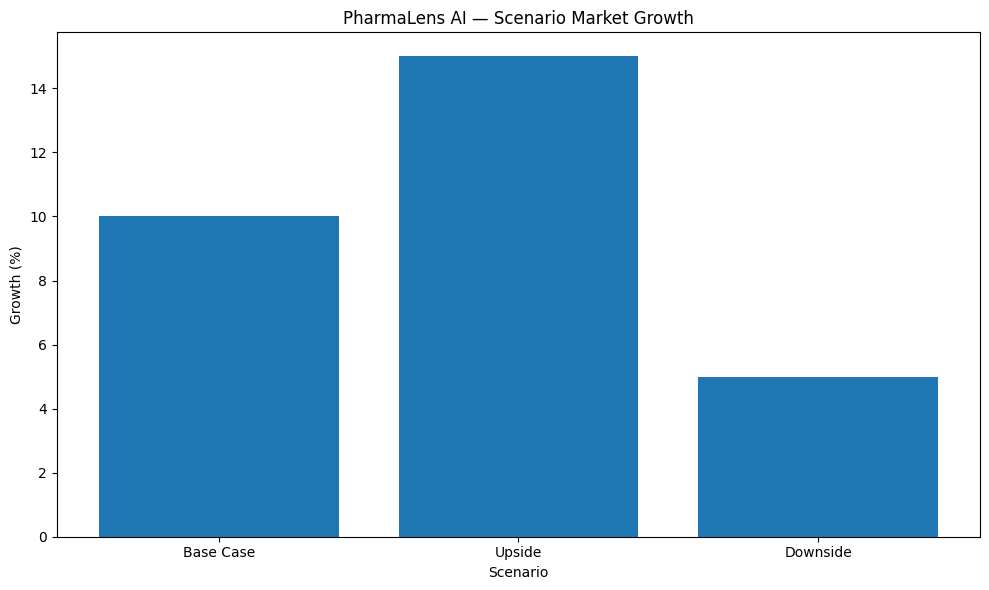

In [10]:
plt.figure(figsize=(10, 6))
plt.bar(market_scenarios['Scenario'], market_scenarios['Market_Value_Growth_%'])
plt.title('PharmaLens AI — Scenario Market Growth')
plt.xlabel('Scenario')
plt.ylabel('Growth (%)')
plt.tight_layout()
plt.show()


## 4. Brand-level scenario intelligence


In [11]:
brand_scenarios = run_brand_scenarios(df, SCENARIOS, months=12)
brand_scenarios = add_opportunity_scores(brand_scenarios)
print('Brand scenario rows:', brand_scenarios.shape)
display(brand_scenarios.head(20))


Brand scenario rows: (24522, 15)


,Brand Name,Manufacturer,Therapeutic Class,Baseline_Sales_Value,Baseline_Sales_Units,Scenario,Projected_Sales_Value,Projected_Sales_Units,Revenue_Change,Revenue_Growth_%,Projected_Market_Share_%,Revenue_Opportunity_Score,Market_Share_Score,Scenario_Opportunity_Score,Strategic_Action
0,123,HIKMA PLC*,R05A0 COLD PREPARATIONS,308205128.0,8970698.0,Base Case,3.390256e+08,9688353.84,30820512.80,10.0,1.055288e-01,6.723778,10.085667,7.73,Deprioritize
1,123 EXTRA,HIKMA PLC*,R05A0 COLD PREPARATIONS,53970175.0,1079403.5,Base Case,5.936719e+07,1165755.78,5397017.50,10.0,1.847928e-02,1.177409,1.766113,1.35,Deprioritize
2,2 HC,NOVACARE*,A11G1 VITAMIN C PLAIN,19080.0,159.0,Base Case,2.098800e+04,171.72,1908.00,10.0,6.532953e-06,0.000416,0.000624,0.00,Deprioritize
3,3 FLY,DRUG PHARMA EGYPT*,N07X0 ALL OTHER CNS DRUGS,22666165.0,89483.0,Base Case,2.493278e+07,96641.64,2266616.50,10.0,7.760849e-03,0.494483,0.741725,0.57,Deprioritize
4,5-FLUOROURACIL,SANDOZ*,L01B0 ANTIMETABOLITES,360500.0,7210.0,Base Case,3.965500e+05,7786.80,36050.00,10.0,1.234345e-04,0.007865,0.011797,0.01,Deprioritize
5,A VITON,KAHIRA*,A11C1 VITAMIN A PLAIN,190.0,10.0,Base Case,2.090000e+02,10.80,19.00,10.0,6.505561e-08,0.000004,0.000006,0.00,Deprioritize
6,ABEVMY,SEDICO/ACDIMA,L01G2 MAB A-NEOPLAS VEGF/VEGFR,38975564.0,3643.0,Base Case,4.287312e+07,3934.44,3897556.40,10.0,1.334515e-02,0.850288,1.275431,0.98,Deprioritize
7,ABILIA,CHEMIPHARM*,N05A1 ATYPICAL ANTIPSYCHOTICS,1050.0,10.0,Base Case,1.155000e+03,10.80,105.00,10.0,3.595179e-07,0.000023,0.000034,0.00,Deprioritize
8,ABILIFY,OTSUKA,N05A1 ATYPICAL ANTIPSYCHOTICS,65545323.5,327943.0,Base Case,7.209986e+07,354178.44,6554532.35,10.0,2.244259e-02,1.429931,2.144897,1.64,Deprioritize
9,ABILIFY MAINTENA,OTSUKA,N05A1 ATYPICAL ANTIPSYCHOTICS,15071586.0,3719.0,Base Case,1.657874e+07,4016.52,1507158.60,10.0,5.160480e-03,0.328800,0.493201,0.38,Deprioritize


In [12]:
top_opportunities = (
    brand_scenarios
    .sort_values(['Scenario','Scenario_Opportunity_Score'], ascending=[True, False])
    .groupby('Scenario', dropna=False)
    .head(20)
    .reset_index(drop=True)
)
display(top_opportunities)


,Brand Name,Manufacturer,Therapeutic Class,Baseline_Sales_Value,Baseline_Sales_Units,Scenario,Projected_Sales_Value,Projected_Sales_Units,Revenue_Change,Revenue_Growth_%,Projected_Market_Share_%,Revenue_Opportunity_Score,Market_Share_Score,Scenario_Opportunity_Score,Strategic_Action
0,ZURCAL,AUG PHARMA*,A02B2 PROTON PUMP INHIBITORS,3.055873e+09,28497134.00,Base Case,3.361460e+09,3.077690e+07,3.055873e+08,10.0,1.046325,66.666667,100.000000,76.67,Invest & Expand
1,GABIMASH,BIOMED PHARMA.*,N02D0 GABAPENTINOID PRODUCTS,2.277846e+09,11033082.00,Base Case,2.505631e+09,1.191573e+07,2.277846e+08,10.0,0.779930,49.693304,74.539957,57.15,Defend & Monitor
2,AUGMENTIN,GLAXOSMITHKLINE*,J01C1 BROAD SPECT PENICILL ORAL,2.252241e+09,12131585.00,Base Case,2.477465e+09,1.310211e+07,2.252241e+08,10.0,0.771163,49.134697,73.702045,56.50,Defend & Monitor
3,MOUNJARO,ELI LILLY*,A10S0 GLP-1 AGONIST A-DIABS,1.948330e+09,133863.00,Base Case,2.143163e+09,1.445720e+05,1.948330e+08,10.0,0.667104,42.504604,63.756907,48.88,Defend & Monitor
4,PANADOL,HALEON*,N02B0 NON-NARCOTIC ANALGESICS,1.925434e+09,21490101.00,Base Case,2.117977e+09,2.320931e+07,1.925434e+08,10.0,0.659265,42.005104,63.007656,48.31,Defend & Monitor
5,CONTROLOC,ACINO*,A02B2 PROTON PUMP INHIBITORS,1.857308e+09,10786769.50,Base Case,2.043039e+09,1.164971e+07,1.857308e+08,10.0,0.635938,40.518875,60.778312,46.60,Defend & Monitor
6,HIBIOTIC,AMOUN PHARM.CO.*,J01C1 BROAD SPECT PENICILL ORAL,1.854552e+09,13923070.00,Base Case,2.040007e+09,1.503692e+07,1.854552e+08,10.0,0.634995,40.458747,60.688120,46.53,Defend & Monitor
7,BRUFEN,ABBOTT*,M01A1 ANTIRHEUMATICS NON-S PLN,1.794916e+09,27242412.48,Base Case,1.974408e+09,2.942181e+07,1.794916e+08,10.0,0.614576,39.157751,58.736626,45.03,Defend & Monitor
8,CLEXANE,SANOFI,B01B2 FRACTIONATED HEPARINS,1.498273e+09,4695908.00,Base Case,1.648100e+09,5.071581e+06,1.498273e+08,10.0,0.513006,32.686198,49.029297,37.59,Selective Investment
9,CONVENTIN,EVA PHARMA*,N02D0 GABAPENTINOID PRODUCTS,1.364732e+09,10410742.94,Base Case,1.501205e+09,1.124360e+07,1.364732e+08,10.0,0.467281,29.772877,44.659316,34.24,Selective Investment


## 5. Downside risk


In [13]:
risk = downside_risk(brand_scenarios)
display(risk.head(20))


,Brand Name,Manufacturer,Therapeutic Class,Projected_Sales_Value_Base,Projected_Sales_Value_Downside,Downside_Revenue_Loss,Downside_Loss_%
0,DICLAC,SANDOZ*,M01A1 ANTIRHEUMATICS NON-S PLN,1.057122e+09,3.250800e+03,1.057119e+09,99.999692
1,TELFAST,SANOFI,R06A0 ANTIHISTAMINES SYSTEMIC,9.873903e+08,6.784609e+07,9.195442e+08,93.128747
2,PANTHENOL,NILE*,D03A9 OTH WOUND HEALING AGENTS,8.565502e+08,3.843000e+04,8.565117e+08,99.995513
3,PANTHENOL,NILE*,D03A9 OTH WOUND HEALING AGENTS,8.565502e+08,2.423662e+05,8.563078e+08,99.971704
4,PANTHENOL,NILE*,D03A9 OTH WOUND HEALING AGENTS,8.565502e+08,1.474400e+06,8.550758e+08,99.827868
5,PANTHENOL,NILE*,D03A9 OTH WOUND HEALING AGENTS,8.565502e+08,1.822485e+06,8.547277e+08,99.787230
6,DEXAMETHASONE PHOS,PHARCO*,H02A1 INJ CORTICOSTEROIDS PLAIN,7.866461e+08,2.472426e+07,7.619219e+08,96.857003
7,FLUMOX,EIPICO/ACDIMA,J01C1 BROAD SPECT PENICILL ORAL,7.699246e+08,6.422025e+07,7.057044e+08,91.658891
8,UNICTAM,MUP/ACDIMA,J01C2 BROAD SPECT PENICILL INJ,6.123106e+08,2.453615e+07,5.877744e+08,95.992859
9,TAVANIC,SANOFI,J01G1 ORAL FLUOROQUINOLONES,5.941580e+08,3.902759e+07,5.551304e+08,93.431446


## 6. Optional Project 11 patient-flow integration


In [14]:
# Replace these example values with the actual Project 11 external-data outputs.
PATIENT_FLOW_BASELINE = {
    'population': 100_000_000,
    'prevalence_rate': 0.05,
    'diagnosis_rate': 0.60,
    'treatment_rate': 0.50,
}

patient_flow = run_patient_flow_scenarios(
    PATIENT_FLOW_BASELINE,
    SCENARIOS,
)
display(patient_flow)


,Population,Disease_Population,Diagnosed_Patients,Treated_Patients,Scenario,Diagnosis_Rate_%,Treatment_Rate_%
0,100000000.0,5000000.0,3000000.0,1500000.0,Base Case,60.0,50.0
1,100000000.0,5000000.0,3150000.0,1653750.0,Upside,63.0,52.5
2,100000000.0,5000000.0,2850000.0,1353750.0,Downside,57.0,47.5


## 7. Executive scenario summary


In [15]:
executive_summary = market_scenarios[[
    'Scenario',
    'Baseline_Market_Value',
    'Projected_Market_Value',
    'Market_Value_Growth_%',
    'Incremental_Revenue',
    'Baseline_Units',
    'Projected_Units',
    'Unit_Growth_%',
]].copy()
display(executive_summary)


,Scenario,Baseline_Market_Value,Projected_Market_Value,Market_Value_Growth_%,Incremental_Revenue,Baseline_Units,Projected_Units,Unit_Growth_%
0,Base Case,2.920578e+11,3.212636e+11,10.0,2.920578e+10,3.133510e+09,3.384190e+09,8.0
1,Upside,2.920578e+11,3.358665e+11,15.0,4.380867e+10,3.133510e+09,3.509531e+09,12.0
2,Downside,2.920578e+11,3.066607e+11,5.0,1.460289e+10,3.133510e+09,3.227515e+09,3.0


## 8. Save Project 12 outputs


In [16]:
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

brand_scenarios.to_parquet(OUTPUT_DIR / 'scenario_results.parquet', index=False)
executive_summary.to_csv(OUTPUT_DIR / 'scenario_summary.csv', index=False)
risk.to_csv(OUTPUT_DIR / 'scenario_downside_risk.csv', index=False)
patient_flow.to_csv(OUTPUT_DIR / 'scenario_patient_flow.csv', index=False)

print('Saved Project 12 outputs to:', OUTPUT_DIR)


Saved Project 12 outputs to: D:\learning\Epsilon\Data Science\PDF lec\Decodelab\PharmaLens AI\data\processed


## 9. Final production test


In [17]:
result = scenario_engine(
    project_root=PROJECT_ROOT,
    scenarios=SCENARIOS,
    months=12,
    patient_flow=PATIENT_FLOW_BASELINE,
)

print('Market:', result['market'].shape)
print('Brands:', result['brands'].shape)
print('Downside risk:', result['downside_risk'].shape)
print('Patient flow:', result['patient_flow'].shape)
print('\nPROJECT 12 — SCENARIO PLANNING COMPLETED SUCCESSFULLY')


Market: (3, 12)
Brands: (24522, 15)
Downside risk: (9158, 7)
Patient flow: (3, 7)

PROJECT 12 — SCENARIO PLANNING COMPLETED SUCCESSFULLY
